In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from functools import reduce
import numpy as np
import pandas as pd
import re
import gc
import datetime as _dt
import pyarrow.parquet as pq
from collections import defaultdict
from dateutil.relativedelta import relativedelta
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.metrics import precision_recall_curve, auc
from deap import base, creator, tools, algorithms
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [3]:
df = pd.read_csv('features_weekly.csv')
df.head()

,user,week_start,week_number,email_external_ratio,email_suspicious_content_ratio,email_bcc_email_ratio,email_external_email_with_attachment_ratio,email_after_hours_or_weekend_ratio,email_max_zscore_emails,email_avg_emails_per_week,...,z_http_avg_requests_per_day,z_http_upload_ratio,z_http_download_ratio,z_http_off_hours_ratio,z_http_suspicious_ratio,psycho_ocean_risk_score,ldap_zscore_departure,users_activity_not_main_pc_ratio,users_post_departure_activity,users_pre_departure_ratio
0,AAB0162,2010-01-04,1,0.222222,0.000000,0.0,0.000000,0.0,0.0,45.00,...,0.000000,0.0,0.0,0.0,0.000000,0.062937,0.27574,0.0,0.0,0.0
1,AAB0162,2010-01-11,2,0.166667,0.000000,0.0,0.011111,0.0,0.0,45.00,...,0.000000,0.0,0.0,0.0,0.000000,0.062937,0.27574,0.0,0.0,0.0
2,AAB0162,2010-01-18,3,0.229630,0.000000,0.0,0.022222,0.0,0.0,45.00,...,0.000000,0.0,0.0,0.0,0.000000,0.062937,0.27574,0.0,0.0,0.0
3,AAB0162,2010-01-25,4,0.216374,0.000000,0.0,0.023392,0.0,0.0,42.75,...,-0.342791,0.0,0.0,0.0,-0.005614,0.062937,0.27574,0.0,0.0,0.0
4,AAB0162,2010-02-01,5,0.208333,0.009259,0.0,0.023148,0.0,0.5,43.20,...,-0.628322,0.0,0.0,0.0,0.000000,0.062937,0.27574,0.0,0.0,0.0


In [4]:
df.columns

Index(['user', 'week_start', 'week_number', 'email_external_ratio',
       'email_suspicious_content_ratio', 'email_bcc_email_ratio',
       'email_external_email_with_attachment_ratio',
       'email_after_hours_or_weekend_ratio', 'email_max_zscore_emails',
       'email_avg_emails_per_week', 'email_avg_size_sent_email',
       'email_zscore_last_month', 'z_email_external_ratio',
       'z_email_suspicious_content_ratio', 'z_email_bcc_email_ratio',
       'z_email_external_email_with_attachment_ratio',
       'z_email_after_hours_or_weekend_ratio', 'z_email_avg_emails_per_week',
       'z_email_avg_size_sent_email', 'file_copy_ratio', 'file_write_ratio',
       'file_delete_ratio', 'file_copy_to_removable_ratio',
       'file_from_removable_ratio', 'file_events_per_file',
       'file_off_hours_ratio', 'file_suspicious_file_content_ratio',
       'file_open_then_copy_ratio', 'file_copy_then_delete_ratio',
       'file_max_zscore_file_activity', 'file_zscore_last_month',
       'decoy_

In [5]:
l = pd.read_csv('cert_dataset/insiders/insiders.csv')
insiders = l[l['dataset']==6.2]['user']
insiders

186    ACM2278
187    CMP2946
188    PLJ1771
189    CDE1846
190    MBG3183
Name: user, dtype: str

In [ ]:
threat_weeks = pd.read_csv('cert_dataset/insiders/threat_weeks.csv')
threat_weeks.head(30)

,user,week_start
0,ACM2278,2010-08-16
1,ACM2278,2010-08-23
2,CDE1846,2011-02-21
3,CDE1846,2011-03-14
4,CDE1846,2011-03-21
5,CDE1846,2011-03-28
6,CDE1846,2011-04-04
7,CDE1846,2011-04-11
8,CDE1846,2011-04-25
9,CMP2946,2011-01-31


In [47]:
if 'is_insider' in df.columns:
    df = df.drop(columns=['is_insider'])

# 2. Préparation du DataFrame de référence
threat_df = pd.DataFrame(threat_weeks, columns=['user', 'week_start'])
threat_df['is_insider'] = 1

# 3. Le Merge
# Note : Vérifie bien que 'user' et 'week_start' ont EXACTEMENT le même nom dans df et threat_df
df = df.merge(threat_df, on=['user', 'week_start'], how='left')

# 4. Remplissage des cases vides (ceux qui ne sont pas dans threat_df)
# Après le merge, les lignes correspondantes ont 1, les autres ont NaN
df['is_insider'] = df['is_insider'].fillna(0).astype(int)

print(df['is_insider'].value_counts())

is_insider
0    284040
1        21
Name: count, dtype: int64


In [ ]:
X = df.drop(columns=['user','is_insider','file_open_then_copy_ratio', 'file_copy_then_delete_ratio','week_start','week_number'])

s_scaler = StandardScaler()

m_scaler = MinMaxScaler()

X_scaled_s = s_scaler.fit_transform(X)

X_scaled_m = m_scaler.fit_transform(X)

model = IsolationForest(
    n_estimators=10000,
    max_samples=150000,
    max_features=1.0,
    random_state=42,
)

model.fit(X_scaled_s)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",10000
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",150000
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [11]:
df['anomaly_score'] = -model.score_samples(X_scaled_s)

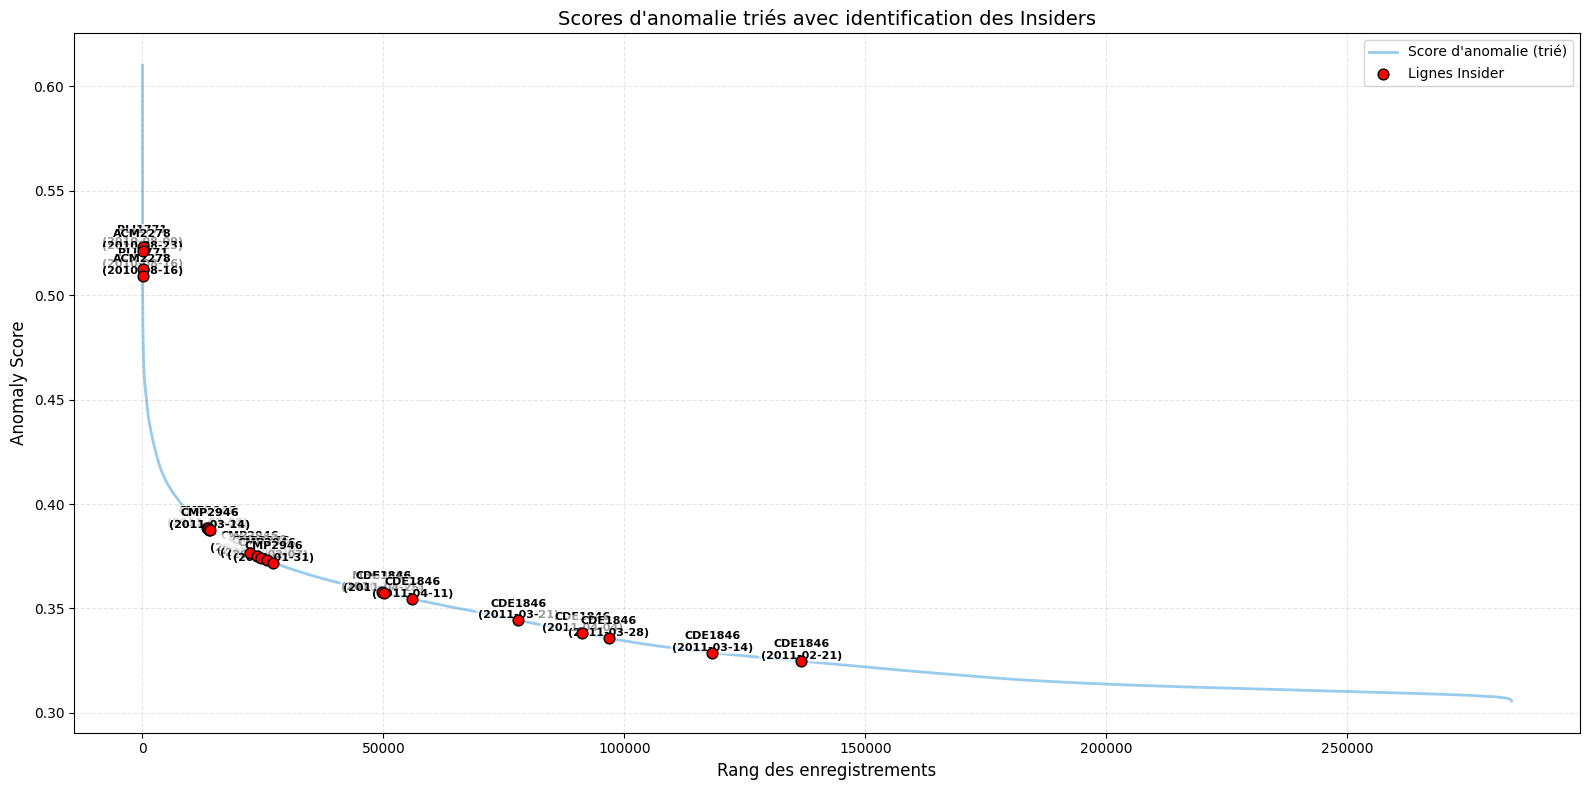

In [50]:
df_sorted = df.sort_values(by='anomaly_score', ascending=False).reset_index(drop=True)

# 2. On récupère les indices des insiders
insider_indices_sorted = df_sorted[df_sorted['is_insider'] >= 1].index

plt.figure(figsize=(16, 8))

# 3. Tracer la courbe des scores
plt.plot(df_sorted.index, df_sorted['anomaly_score'], 
         label="Score d'anomalie (trié)", 
         color='#3498db', 
         alpha=0.5, 
         linewidth=2)

# 4. Marquer les insiders et ajouter les étiquettes
if len(insider_indices_sorted) > 0:
    # On trace les points
    plt.scatter(insider_indices_sorted, 
                df_sorted.loc[insider_indices_sorted, 'anomaly_score'], 
                color='red', 
                label='Lignes Insider', 
                s=60, 
                zorder=5,
                edgecolors='black')

    # On ajoute le texte pour chaque point insider
    for idx in insider_indices_sorted:
        user = df_sorted.loc[idx, 'user']
        week = df_sorted.loc[idx, 'week_start']
        score = df_sorted.loc[idx, 'anomaly_score']
        
        # Format de l'étiquette : Nom de l'user + date (tronquée si nécessaire)
        label = f"{user}\n({week})"
        
        plt.text(idx, score, label, 
                 fontsize=8, 
                 fontweight='bold',
                 verticalalignment='bottom', 
                 horizontalalignment='center',
                 bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1))

# Mise en forme
plt.title("Scores d'anomalie triés avec identification des Insiders", fontsize=14)
plt.xlabel("Rang des enregistrements", fontsize=12)
plt.ylabel("Anomaly Score", fontsize=12)
plt.legend()
plt.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

In [32]:
df.sort_values(by='anomaly_score',ascending=False)[['user','anomaly_score']].head()

,user,anomaly_score
40294,BVB1673,0.610084
40292,BVB1673,0.594605
40295,BVB1673,0.571874
40293,BVB1673,0.570811
216724,QRJ1597,0.556791


In [45]:
df_scores = pd.DataFrame({'user': df['user'], 'score': df['anomaly_score']})
df_scores = df_scores.sort_values('score', ascending=False)
df_scores['rank'] = range(1, len(df_scores) + 1)

print("Ranking des insiders :")
print(df_scores[df_scores['user'].isin(insiders)][['user', 'score', 'rank']])

Ranking des insiders :
         user     score  rank
2987  PLJ1771  0.548783    45
815   CMP2946  0.544474    48
64    ACM2278  0.533018    68
2488  MBG3183  0.431045   761
676   CDE1846  0.410538  1072


### Genetic Algorithm

In [29]:
df = pd.read_csv('features_v3.csv')

X = df.drop(columns='user')

In [30]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

In [31]:
N_FEATURES = len(X.columns)
INSIDERS =  l[l['dataset']==6.2]['user']
K = 25

In [33]:
def fitness_function(individual):

    selected = [col for col, bit in zip(X.columns, individual) if bit == 1]

    if len(selected) == 0:
        return (0.0,)
    
    X_selected = X_scaled[selected]

    clf = IsolationForest(
        n_estimators=1000,
        random_state=42,
        max_samples=2000,
        max_features=1.0,
    )

    clf.fit(X_selected)
    scores = -clf.score_samples(X_selected)
    df_scores = pd.DataFrame({'user':df['user'],'score':scores})
    df_scores = df_scores.sort_values('score',ascending=False)
    df_scores['rank'] = range(1,len(df_scores)+1)

    total_users = len(df_scores)
    insider_ranks = df_scores[df_scores['user'].isin(INSIDERS)]['rank'].values

    if len(insider_ranks) == 0:
        return (0.0,)
    
    mean_rank = np.mean(insider_ranks) / total_users

    top_k_hits = np.sum(insider_ranks <= K) / len(INSIDERS)

    alpha = 0.6

    fitness = alpha * (1-mean_rank) + (1 - alpha) * top_k_hits

    return (fitness,)

In [34]:
creator.create('FitnessMax', base.Fitness, weights=(1.0,))
creator.create('Individual', list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()

toolbox.register('attr_bool',np.random.randint,0,2)
toolbox.register('individual',tools.initRepeat,
                 creator.Individual, toolbox.attr_bool, n=N_FEATURES)
toolbox.register('population',tools.initRepeat,
                 list,toolbox.individual)
toolbox.register('evaluate',fitness_function)

toolbox.register('mate', tools.cxTwoPoint)
toolbox.register('mutate',tools.mutFlipBit,indpb=0.05)
toolbox.register('select',tools.selTournament,tournsize=3)

In [35]:
def run_ga(pop_size=100,n_gen=20):

    pop = toolbox.population(n=pop_size)
    hof = tools.HallOfFame(1)

    stats = tools.Statistics(lambda ind : ind.fitness.values)
    stats.register('max', np.max)
    stats.register('mean',np.mean)

    algorithms.eaSimple(
        pop, toolbox,
        cxpb=0.7, mutpb=0.2,
        ngen=n_gen,
        stats=stats,
        halloffame=hof,
        verbose=True
    )

    return hof[0]

best = run_ga()

best_features = [col for col, bit in zip(X.columns, best) if bit == 1]
print(f"Features sélectionnées ({len(best_features)}) :", best_features)
print("Fitness :", best.fitness.values[0])

gen	nevals	max    	mean    
0  	100   	0.77922	0.576583
1  	70    	0.77781	0.615648
2  	69    	0.80178	0.661422
3  	74    	0.81021	0.694278
4  	77    	0.81378	0.705961
5  	74    	0.81471	0.74702 
6  	70    	0.81471	0.766943
7  	77    	0.81936	0.786329
8  	66    	0.81819	0.786711
9  	66    	0.81951	0.797261
10 	81    	0.82278	0.802141
11 	78    	0.82143	0.803109
12 	72    	0.82314	0.807298
13 	80    	0.82473	0.813109
14 	77    	0.82647	0.811305
15 	68    	0.83061	0.814865
16 	79    	0.83076	0.812234
17 	77    	0.83166	0.819332
18 	73    	0.83118	0.817649
19 	70    	0.83325	0.819064
20 	82    	0.83325	0.821004
Features sélectionnées (11) : ['email_max_zscore_emails', 'email_zscore_last_month', 'file_copy_ratio', 'file_delete_ratio', 'file_copy_to_removable_ratio', 'file_from_removable_ratio', 'file_max_zscore_file_activity', 'device_max_zscore_device_week', 'device_ratio_device_conn_after_hours', 'device_zscore_last_month', 'http_job_search_score']
Fitness : 0.8332499999999999


In [36]:
X_with_best_features = X_scaled[best_features]

model = IsolationForest(
    n_estimators=100000,
    max_samples=4000,
    max_features=1.0,
    random_state=42
)

model.fit(X_with_best_features)

IsolationForest(max_samples=4000, n_estimators=100000, random_state=42)

In [37]:
df['anomaly_score_best_features'] = -model.score_samples(X_with_best_features)

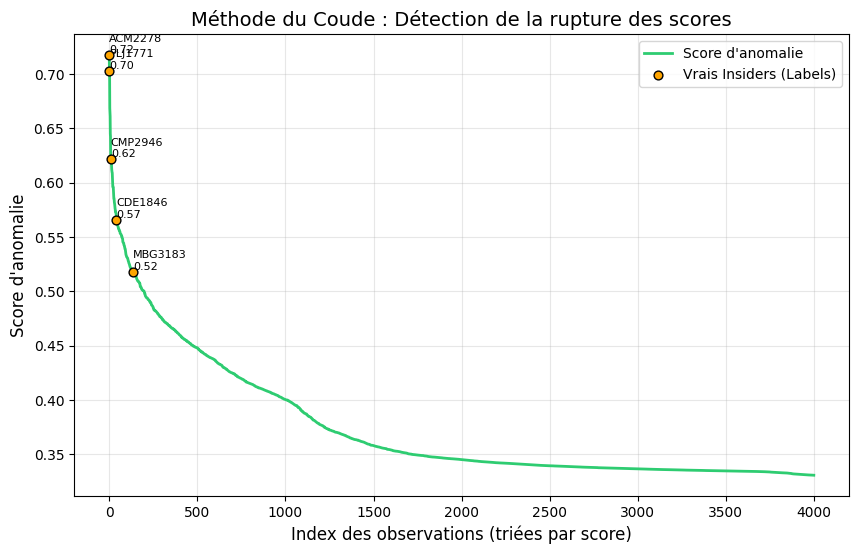

In [38]:
df['is_insider'] = df['user'].isin(insiders).astype(int)
df['is_insider'].value_counts()

sorted_indices = np.argsort(df['anomaly_score_best_features'].values)[::-1]

sorted_scores = df['anomaly_score_best_features'].values[sorted_indices]

sorted_insiders = df['is_insider'].values[sorted_indices]

sorted_users = df['user'].values[sorted_indices]

insider_plot_indices = np.where(sorted_insiders == 1)[0]

plt.figure(figsize=(10, 6))

plt.plot(range(len(sorted_scores)), sorted_scores, label='Score d\'anomalie', color='#2ecc71', linewidth=2)

plt.scatter(insider_plot_indices, sorted_scores[insider_plot_indices], 
            color='orange', label='Vrais Insiders (Labels)', zorder=5, s=40, edgecolors='black')

for i in insider_plot_indices:
    user_id = sorted_users[i]
    score = sorted_scores[i]
    
    plt.text(i, score,
             f"{user_id}\n{score:.2f}",
             fontsize=8,
             ha='left',
             va='bottom')
    
plt.title("Méthode du Coude : Détection de la rupture des scores", fontsize=14)

plt.xlabel("Index des observations (triées par score)", fontsize=12)

plt.ylabel("Score d'anomalie", fontsize=12)

plt.legend()

plt.grid(alpha=0.3)

plt.show()

### Encoder

In [8]:
df = pd.read_csv('features_v3.csv')

X = df.drop(columns='user')

In [9]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

In [10]:
l = pd.read_csv('cert_dataset/insiders/insiders.csv')
INSIDERS = l[l['dataset']==6.2]['user']

In [ ]:
X_train = X_scaled[~df['user'].isin(INSIDERS)]
X_tensor_train = torch.FloatTensor(X_train.values)

X_tensor_all = torch.FloatTensor(X_scaled.values)

dataset = TensorDataset(X_tensor_train)
loader = DataLoader(dataset, batch_size=64, shuffle=True)

In [32]:
class Autoencoder(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        
        self.encoder = nn.Sequential(
            nn.Linear(n_features, 48),  
            nn.ReLU(),
            nn.Linear(48, 24),          
            nn.ReLU(),
            nn.Linear(24, 12),        
            nn.ReLU(),
            nn.Linear(12, 4),           
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(4, 12),
            nn.ReLU(),
            nn.Linear(12, 24),
            nn.ReLU(),
            nn.Linear(24, 48),
            nn.ReLU(),
            nn.Linear(48, n_features), 
        )
    
    def forward(self, x):
        return self.decoder(self.encoder(x))

model = Autoencoder(n_features=X_scaled.shape[1])
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
criterion = nn.MSELoss()

best_loss = float('inf')
best_state = None

for epoch in range(1000):
    model.train()
    epoch_loss = 0
    for (batch,) in loader:
        reconstructed = model(batch)
        loss = criterion(reconstructed, batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / len(loader)
    
    if avg_loss < best_loss:
        best_loss = avg_loss
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
    
    if epoch % 20 == 0:
        print(f"Epoch {epoch} — Loss: {avg_loss:.4f}")

model.load_state_dict(best_state)

Epoch 0 — Loss: 0.9744
Epoch 20 — Loss: 0.4155
Epoch 40 — Loss: 0.3585
Epoch 60 — Loss: 0.3313
Epoch 80 — Loss: 0.3143
Epoch 100 — Loss: 0.2994
Epoch 120 — Loss: 0.2883
Epoch 140 — Loss: 0.2753
Epoch 160 — Loss: 0.2696
Epoch 180 — Loss: 0.2673
Epoch 200 — Loss: 0.2627
Epoch 220 — Loss: 0.2612
Epoch 240 — Loss: 0.2563
Epoch 260 — Loss: 0.2532
Epoch 280 — Loss: 0.2508
Epoch 300 — Loss: 0.2488
Epoch 320 — Loss: 0.2462
Epoch 340 — Loss: 0.2458
Epoch 360 — Loss: 0.2454
Epoch 380 — Loss: 0.2421
Epoch 400 — Loss: 0.2425
Epoch 420 — Loss: 0.2405
Epoch 440 — Loss: 0.2396
Epoch 460 — Loss: 0.2407
Epoch 480 — Loss: 0.2368
Epoch 500 — Loss: 0.2375
Epoch 520 — Loss: 0.2343
Epoch 540 — Loss: 0.2351
Epoch 560 — Loss: 0.2339
Epoch 580 — Loss: 0.2322
Epoch 600 — Loss: 0.2338
Epoch 620 — Loss: 0.2321
Epoch 640 — Loss: 0.2318
Epoch 660 — Loss: 0.2303
Epoch 680 — Loss: 0.2299
Epoch 700 — Loss: 0.2290
Epoch 720 — Loss: 0.2295
Epoch 740 — Loss: 0.2298
Epoch 760 — Loss: 0.2284
Epoch 780 — Loss: 0.2285
Epoch 

<All keys matched successfully>

In [33]:
K = 25

model.eval()
with torch.no_grad():
    reconstructed = model(X_tensor_all)
    errors = torch.mean((X_tensor_all - reconstructed) ** 2, dim=1).numpy()

df_scores = pd.DataFrame({'user': df['user'], 'score': errors})
df_scores = df_scores.sort_values('score', ascending=False)
df_scores['rank'] = range(1, len(df_scores) + 1)

print("Ranking des insiders :")
print(df_scores[df_scores['user'].isin(INSIDERS)][['user', 'score', 'rank']])
print(f"\nTop-{K} hit rate : {(df_scores[df_scores['user'].isin(INSIDERS)]['rank'] <= K).sum()} / {len(INSIDERS)}")

mean_rank = df_scores[df_scores['user'].isin(INSIDERS)]['rank'].mean()
print(f"Mean rank : {mean_rank:.1f} / {len(df_scores)}")

Ranking des insiders :
         user      score  rank
64    ACM2278  10.672123     1
2987  PLJ1771   5.137519     2
815   CMP2946   1.438446    16
676   CDE1846   0.913109    63
2488  MBG3183   0.264687  1153

Top-25 hit rate : 3 / 5
Mean rank : 247.0 / 4000
